# Student Performance Prediction - walkthrough

Ovaj notebook je pomoćni materijal za razumevanje projekta, pripremu odbrane i kasnije pisanje formalne dokumentacije. Ne predstavlja glavni fajl za predaju, već objašnjava korake koji su urađeni u `.py` skriptama i prikazuje njihove CSV izveštaje i grafike.


## 1. Kratak opis projekta

Cilj projekta je predikcija završne ocene učenika, odnosno promenljive **G3**, na osnovu dostupnih atributa iz dataset-a `student-por.csv`.

Projekat se radi postepeno: prvo je urađena priprema podataka, zatim eksplorativna analiza, potom podela na train/validation/test skupove, osnovno treniranje modela i grafičko poređenje rezultata. Sledeći veći korak biće podešavanje hiperparametara.


## 2. Opis dataset-a

Dataset se nalazi na putanji `data/raw/student-por.csv`.

Podaci potiču iz istraživanja školskog uspeha učenika u Portugalu. Dataset sadrži demografske, porodične, školske i ponašajne atribute učenika, kao i njihove ocene.

Važno je zapamtiti da su ocene u ovom dataset-u na skali **0-20**, a ne na skali 1-5.

- **G1** je ocena iz prvog perioda.
- **G2** je ocena iz drugog perioda.
- **G3** je završna ocena i ciljna promenljiva koju želimo da predvidimo.

In [1]:
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "student-por.csv"
STEP01_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step01_data_preparation"
STEP02_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step02_eda"
STEP02_GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "step02_eda"
STEP03_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step03_data_split"
STEP04_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step04_model_training"
STEP05_GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "step05_model_comparison"
STEP06_LOGS_DIR = PROJECT_ROOT / data / logs / step06_hyperparameter_tuning
STEP07_GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "step07_tuning_graphs"


In [2]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "student-por.csv"
STEP01_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step01_data_preparation"
STEP02_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step02_eda"
STEP02_GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "step02_eda"
STEP03_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step03_data_split"
STEP04_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step04_model_training"
STEP05_GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "step05_model_comparison"
STEP06_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step06_hyperparameter_tuning"

df = pd.read_csv(DATA_PATH)
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


## 3. Zašto je ovo regresioni problem?

Ovo je regresioni problem zato što je ciljna promenljiva **G3 numerička vrednost**. Model treba da predvidi brojčanu završnu ocenu učenika na skali 0-20.

Kod klasifikacije bismo predviđali klasu ili kategoriju, na primer `položio` / `nije položio`. Ovde ne predviđamo kategoriju, već konkretnu numeričku ocenu, pa je zadatak regresija.

## 4. Zašto posebno analiziramo G1 i G2?

**G1** i **G2** su prethodne ocene učenika. Pošto predstavljaju raniji uspeh istog učenika, očekivano je da budu jako povezane sa završnom ocenom **G3**.

Zbog toga će model koji koristi G1 i G2 verovatno imati bolje rezultate. Međutim, model bez G1 i G2 može biti praktično korisniji, jer omogućava raniju procenu uspeha učenika, pre nego što su prethodne periodične ocene poznate ili kada želimo da se oslonimo samo na druge karakteristike.

## 5. Planirani scenariji modelovanja

U projektu su trenutno pripremljena dva glavna scenarija:

- **with_G1_G2**: koriste se svi ulazni atributi osim ciljne promenljive G3.
- **without_G1_G2**: koriste se svi ulazni atributi osim G1, G2 i G3.

Postoji i plan za treći scenario, **top_features**, ali on se još ne implementira. Biće definisan kasnije, nakon treniranja modela i analize važnosti atributa, odnosno feature importance analize.

# Step 01 - Priprema podataka

Fajl `src/step01_data_preparation.py` objedinjuje prvi korak pripreme podataka. On:

- ucitava dataset,
- proverava missing vrednosti,
- proverava duplikate,
- proverava osnovne anomalije,
- proverava da li su G1, G2 i G3 u ocekivanom opsegu 0-20,
- definise ciljnu promenljivu G3,
- definise scenarije `with_G1_G2` i `without_G1_G2`,
- priprema preprocessing logiku,
- generise CSV izvestaje u folderu `data/logs/step01_data_preparation/`.

U ovom koraku se ne trenira model, ne pravi se train/test split, ne fituje se `ColumnTransformer` i ne prave se grafici.

## 7. CSV izveštaji

Skripta `step01_data_preparation.py` generiše tri CSV izveštaja:

- `data/logs/step01_data_preparation/dataset_overview.csv`
- `data/logs/step01_data_preparation/features_overview.csv`
- `data/logs/step01_data_preparation/preprocessing_report.csv`

Ovi fajlovi služe da se rezultati prvog koraka ne objašnjavaju samo kroz kod, već i kroz čitljive izveštaje koji se mogu koristiti tokom odbrane i pri pisanju dokumentacije.

### 7.1 `dataset_overview.csv`

Ovaj izveštaj daje osnovni pregled dataset-a: broj redova i kolona, broj duplikata, broj nedostajućih vrednosti, broj numeričkih i kategorijskih kolona, kao i osnovne informacije o ocenama G1, G2 i G3.

In [3]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "student-por.csv"
STEP01_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step01_data_preparation"
STEP02_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step02_eda"
STEP02_GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "step02_eda"
STEP03_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step03_data_split"
STEP04_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step04_model_training"
STEP05_GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "step05_model_comparison"
STEP06_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step06_hyperparameter_tuning"

dataset_overview = pd.read_csv(STEP01_LOGS_DIR / "dataset_overview.csv")
dataset_overview

,Opis,Vrednost
0,Broj redova,649
1,Broj kolona,33
2,Broj duplikata,0
3,Ukupan broj nedostajućih vrednosti,0
4,Broj numeričkih kolona,16
5,Broj kategorijskih kolona,17
6,Minimalna završna ocena G3,0
7,Maksimalna završna ocena G3,19
8,Prosečna završna ocena G3,11.91
9,Prosečna ocena G1,11.40


### 7.2 `features_overview.csv`

Ovaj izveštaj opisuje svaku kolonu u dataset-u. Za svaku kolonu prikazuje tip podatka, da li je numerička, kategorijska ili ciljna promenljiva, broj missing vrednosti, broj jedinstvenih vrednosti i da li se kolona koristi u scenarijima sa G1 i G2 ili bez G1 i G2.

Posebno je važno primetiti da se **G3** ne koristi kao ulazni atribut, jer je to ciljna promenljiva.

In [4]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "student-por.csv"
STEP01_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step01_data_preparation"
STEP02_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step02_eda"
STEP02_GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "step02_eda"
STEP03_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step03_data_split"
STEP04_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step04_model_training"
STEP05_GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "step05_model_comparison"
STEP06_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step06_hyperparameter_tuning"

features_overview = pd.read_csv(STEP01_LOGS_DIR / "features_overview.csv")
features_overview

,column,dtype,feature_type,missing_values,unique_count,unique_values,used_with_G1_G2,used_without_G1_G2,note
0,school,str,categorical,0,2,GP; MS,Da,Da,input feature
1,sex,str,categorical,0,2,F; M,Da,Da,input feature
2,age,int64,numeric,0,8,numeric,Da,Da,input feature
3,address,str,categorical,0,2,R; U,Da,Da,input feature
4,famsize,str,categorical,0,2,GT3; LE3,Da,Da,input feature
5,Pstatus,str,categorical,0,2,A; T,Da,Da,input feature
6,Medu,int64,numeric,0,5,numeric,Da,Da,input feature
7,Fedu,int64,numeric,0,5,numeric,Da,Da,input feature
8,Mjob,str,categorical,0,5,at_home; health; other; services; teacher,Da,Da,input feature
9,Fjob,str,categorical,0,5,at_home; health; other; services; teacher,Da,Da,input feature


### 7.3 `preprocessing_report.csv`

Ovaj izveštaj sažima informacije vezane za početni preprocessing: missing vrednosti, duplikate, opseg ocena, anomalije u starosti, maksimalan broj izostanaka, ciljnu promenljivu, scenarije modelovanja, planirani preprocessing i status `top_features` scenarija.

In [5]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "student-por.csv"
STEP01_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step01_data_preparation"
STEP02_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step02_eda"
STEP02_GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "step02_eda"
STEP03_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step03_data_split"
STEP04_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step04_model_training"
STEP05_GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "step05_model_comparison"
STEP06_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step06_hyperparameter_tuning"

preprocessing_report = pd.read_csv(STEP01_LOGS_DIR / "preprocessing_report.csv")
preprocessing_report

,Opis,Vrednost
0,Missing vrednosti,0
1,Duplikati,0
2,G1 van opsega 0-20,Ne
3,G2 van opsega 0-20,Ne
4,G3 van opsega 0-20,Ne
5,Age anomalije,Ne
6,Maksimalan broj izostanaka,32
7,Ciljna promenljiva,G3
8,Scenario sa G1 i G2,32 atributa; koriste se svi ulazni atributi os...
9,Scenario bez G1 i G2,30 atributa; koriste se svi ulazni atributi os...


## 8. Šta znači numeric i categorical feature?

**Numeric feature** je atribut koji je predstavljen brojevima. Primeri su `age`, `absences`, `G1`, `G2` i slične kolone.

**Categorical feature** je atribut koji predstavlja kategoriju ili tekstualnu vrednost. Primeri su `school`, `sex`, `address`, `Mjob`, `Fjob` i slične kolone.

Ova podela je važna zato što se numerički i kategorijski atributi ne pripremaju na isti način. Numerički atributi se kasnije skaliraju, dok se kategorijski atributi kasnije enkodiraju.

## 9. Šta znači StandardScaler + OneHotEncoder?

`StandardScaler` se koristi za numeričke kolone. Njegova uloga je da numeričke vrednosti dovede na uporedivu skalu, što je korisno za mnoge algoritme mašinskog učenja.

`OneHotEncoder` se koristi za kategorijske kolone. On tekstualne kategorije pretvara u numerički oblik koji model može da koristi.

`ColumnTransformer` omogućava da se različite grupe kolona obrade različitim metodama. U ovom projektu to znači da se numeričke kolone obrađuju pomoću `StandardScaler`, a kategorijske kolone pomoću `OneHotEncoder(handle_unknown="ignore")`.

U ovom koraku se preprocessing samo priprema. To znači da objekti postoje u kodu, ali se ne poziva `.fit()`, ne pravi se train/test split i ne trenira se model.

## Objašnjenje najvažnijih delova koda iz `step01_data_preparation.py`

Ova sekcija ne kopira ceo Python fajl, nego izdvaja delove koje je najvažnije razumeti za odbranu. Cilj je da možemo jasno da objasnimo šta prvi korak projekta radi i zašto je urađen baš na taj način.

### 1. Definisanje putanja pomoću `pathlib Path`

U skripti se putanje definišu pomoću `Path`, na primer:

```python
PROJECT_ROOT = Path(__file__).resolve().parents[1]
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "student-por.csv"
LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step01_data_preparation"
```

Ideja je da se prvo pronađe koren projekta, a zatim da se na njega nadovežu relativne putanje do dataset-a i log foldera. U nekim objašnjenjima se za koren projekta koristi naziv `BASE_DIR`; u ovom fajlu se ista ideja zove `PROJECT_ROOT`.

Ovo je bolje nego ručno pisanje apsolutnih putanja, jer apsolutna putanja važi samo na jednom računaru. Ako projekat prebacimo na drugi računar, `Path` pristup i dalje radi dokle god je struktura foldera ista.

### 2. Učitavanje dataset-a

Dataset se učitava pomoću pandas biblioteke:

```python
dataset = pd.read_csv(DATA_PATH)
```

U samoj skripti promenljiva se zove `df`, ali značenje je isto: učitavaju se podaci iz `data/raw/student-por.csv` u tabelarni oblik, da bi mogli da se analiziraju kolonama i redovima.

### 3. Funkcija `save_csv_if_changed`

Ova funkcija služi da se CSV fajlovi ne prepisuju bez potrebe. Skraćena logika izgleda ovako:

```python
if not path.exists():
    new_dataframe.to_csv(path, index=False)
elif existing_dataframe.equals(new_dataframe_for_compare):
    print("CSV fajl nije promenjen")
else:
    new_dataframe.to_csv(path, index=False)
```

Ako CSV ne postoji, funkcija ga kreira. Ako CSV postoji i sadržaj je isti, fajl se ne menja. Ako CSV postoji, ali se sadržaj razlikuje, fajl se ažurira.

Ovo je korisno zato što `git status` ostaje čist kada nema stvarnih promena. Drugim rečima, skripta ne pravi lažne izmene samo zato što je ponovo pokrenuta.

### 4. Pravljenje `dataset_overview.csv`

`dataset_overview.csv` je ljudski čitljiv pregled dataset-a. On ne služi za treniranje modela, nego za brzo razumevanje osnovnog stanja podataka.

U njemu se nalaze informacije kao što su broj redova, broj kolona, broj missing vrednosti, broj duplikata i osnovne statistike za ocene G1, G2 i G3. Na odbrani se ovaj fajl može koristiti da se pokaže da je dataset pregledan pre bilo kakvog modelovanja.

### 5. Pravljenje `features_overview.csv`

`features_overview.csv` objedinjuje pregled svih atributa. Za svaku kolonu prikazuje naziv kolone, tip podatka, da li je kolona `numeric`, `categorical` ili `target`, broj missing vrednosti, broj jedinstvenih vrednosti i način korišćenja u scenarijima.

Posebno je važno sledeće:

- **G3** je target i ne koristi se kao ulazni atribut.
- **G1** i **G2** su numerički atributi i koriste se samo u scenariju `with_G1_G2`.
- Ostali atributi se koriste u oba scenarija.

Ovaj CSV je praktičan jer na jednom mestu pokazuje i tehnički tip kolone i njenu ulogu u projektu.

### 6. Definisanje scenarija

Dva scenarija se mogu objasniti ovim pseudokodom:

```python
features_with_g1_g2 = sve kolone osim G3
features_without_g1_g2 = sve kolone osim G1, G2 i G3
```

Prvi scenario koristi prethodne ocene G1 i G2, pa očekujemo da će kasnije dati bolje rezultate. Drugi scenario ih izbacuje, jer želimo da proverimo koliko model može biti koristan kada se uspeh učenika procenjuje ranije ili bez oslanjanja na prethodne ocene.

### 7. Priprema preprocessing-a

Preprocessing se priprema tako što se numeričke i kategorijske kolone obrađuju različito:

```python
ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)
```

Numeričke kolone idu kroz `StandardScaler`, koji ih kasnije dovodi na uporedivu skalu. Kategorijske kolone idu kroz `OneHotEncoder`, koji tekstualne kategorije pretvara u numerički oblik. `ColumnTransformer` omogućava da se ove dve grupe kolona obrade različitim postupcima u istom preprocessing koraku.

U ovom koraku se preprocessing samo priprema. Ne poziva se `.fit()`, ne radi se train/test split i ne trenira se model.

### Kako bih ovo objasnio na odbrani?

U prvom koraku sam pripremio dataset za kasniju analizu i modelovanje. Prvo sam učitao podatke iz `student-por.csv` i proverio osnovne informacije, kao što su broj redova, broj kolona, missing vrednosti i duplikati. Zatim sam proverio da li su ocene G1, G2 i G3 u očekivanom opsegu od 0 do 20. Posebno sam izdvojio G3 kao ciljnu promenljivu, jer nju želimo da predvidimo. Definisao sam dva scenarija: jedan u kome koristimo G1 i G2 i drugi u kome ih ne koristimo. Na kraju sam pripremio preprocessing logiku, gde će se numeričke kolone skalirati, a kategorijske enkodirati. U ovom koraku još nema treniranja modela, već se samo proverava i organizuje dataset za sledeće faze projekta.


## 10. Kratak zaključak posle prvog koraka

Posle prvog koraka dataset je učitan i pregledan. Na osnovu CSV izveštaja može se proveriti da li postoje nedostajuće vrednosti, duplikati, anomalije i kolone koje bi bile očigledni kandidati za uklanjanje.

Prema trenutnom `preprocessing_report.csv`, dataset nema nedostajuće vrednosti i duplikate, a G1, G2 i G3 su u očekivanom opsegu 0-20. Takođe, nema očiglednih ID ili konstantnih kolona za uklanjanje.

Sledeći korak projekta biće EDA analiza i grafici, kako bi se bolje razumele veze između atributa i ciljne promenljive G3.

# Step 02 - Eksplorativna analiza podataka

U drugom koraku projekta radi se eksplorativna analiza podataka kroz fajl `src/step02_eda.py`. Taj korak sluzi da razumemo raspodelu zavrsne ocene, da proverimo korelacije izmedju numerickih atributa i da uocimo anomalije ili ekstremne vrednosti koje mogu biti vazne za kasnije modelovanje.

Ovaj korak pokriva tri stvari: analizu korelacija, analizu anomalija i pregled ekstremnih vrednosti. Zbog toga gledamo G3 distribuciju, korelacionu matricu, scatter plotove i raspodelu izostanaka.

Grafici koji se nalaze u `data/graphs/step02_eda/` su:

- `g3_distribution.png`
- `numeric_correlation_matrix.png`
- `g1_vs_g3.png`
- `g2_vs_g3.png`
- `failures_vs_g3.png`
- `studytime_vs_g3.png`
- `absences_distribution.png`

## Korelacija i zakljucak iz korelacija

Korelacija pokazuje koliko se dve numericke promenljive krecu zajedno. Vrednost korelacije je izmedju -1 i 1. Ako je korelacija pozitivna, to znaci da kada jedna vrednost raste, uglavnom raste i druga. Ako je korelacija negativna, to znaci da kada jedna vrednost raste, druga uglavnom opada. Ako je korelacija blizu 0, to znaci da nema jake linearne veze izmedju te dve promenljive.

U ovom projektu najvaznije je gledati korelacije atributa sa ciljnom promenljivom `G3`, jer `G3` predstavlja zavrsnu ocenu koju zelimo da predvidimo. Prema EDA izvestaju, `G1` ima jaku pozitivnu korelaciju sa `G3` od 0.83, dok `G2` ima jos jacu pozitivnu korelaciju sa `G3` od 0.92. To znaci da ucenici koji imaju vece prethodne ocene najcesce imaju i vecu zavrsnu ocenu. Posebno je vazno sto je `G2` najjace povezan sa `G3`, jer je druga periodicka ocena vremenski najbliza zavrsnoj oceni.

Sa druge strane, `failures` ima negativnu korelaciju sa `G3` od -0.39, sto znaci da veci broj prethodnih neuspeha uglavnom ide uz nizu zavrsnu ocenu. `studytime` ima slabiju pozitivnu korelaciju od 0.25, pa vreme ucenja moze imati uticaj, ali nije toliko jako povezano sa zavrsnom ocenom kao G1 i G2. `absences` ima korelaciju -0.09, sto je vrlo slaba negativna veza, pa broj izostanaka sam po sebi ne objasnjava dobro zavrsnu ocenu.

Glavni zakljucak iz korelacija je da su `G1` i posebno `G2` najvazniji atributi za predikciju `G3`. Zbog toga kasnije poredimo dva scenarija: jedan u kome modeli koriste `G1` i `G2`, i drugi u kome se `G1` i `G2` izbacuju. Tako mozemo da vidimo koliko model zavisi od prethodnih ocena i koliko dobro moze da predvidi zavrsnu ocenu bez njih.

Fajl `data/logs/step02_eda/eda_report.csv` sadrzi sazetak najvaznijih nalaza: broj ucenika, opseg i prosecnu vrednost G3, broj ucenika sa G3 = 0, kljucne korelacije, najjacu korelaciju sa G3 i zakljucak iz EDA analize.

## EDA izveštaj

Ova ćelija samo učitava postojeći `eda_report.csv` i prikazuje ga, bez pravljenja novih statistika.

In [6]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "student-por.csv"
STEP01_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step01_data_preparation"
STEP02_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step02_eda"
STEP02_GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "step02_eda"
STEP03_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step03_data_split"
STEP04_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step04_model_training"
STEP05_GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "step05_model_comparison"
STEP06_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step06_hyperparameter_tuning"

eda_report = pd.read_csv(STEP02_LOGS_DIR / "eda_report.csv")
eda_report

,Opis,Vrednost
0,Broj učenika,649
1,Minimalna G3 ocena,0
2,Maksimalna G3 ocena,19
3,Prosečna G3 ocena,11.91
4,Broj učenika sa G3 = 0,15
5,Procenat učenika sa G3 = 0,2.31
6,Korelacija G1 i G3,0.83
7,Korelacija G2 i G3,0.92
8,Korelacija G1 i G2,0.86
9,Korelacija failures i G3,-0.39


## EDA Grafici

Sledeće ćelije samo prikazuju već sačuvane PNG fajlove iz `data/graphs/step02_eda/`. Ne generiše se ništa novo.

Raspodela G3


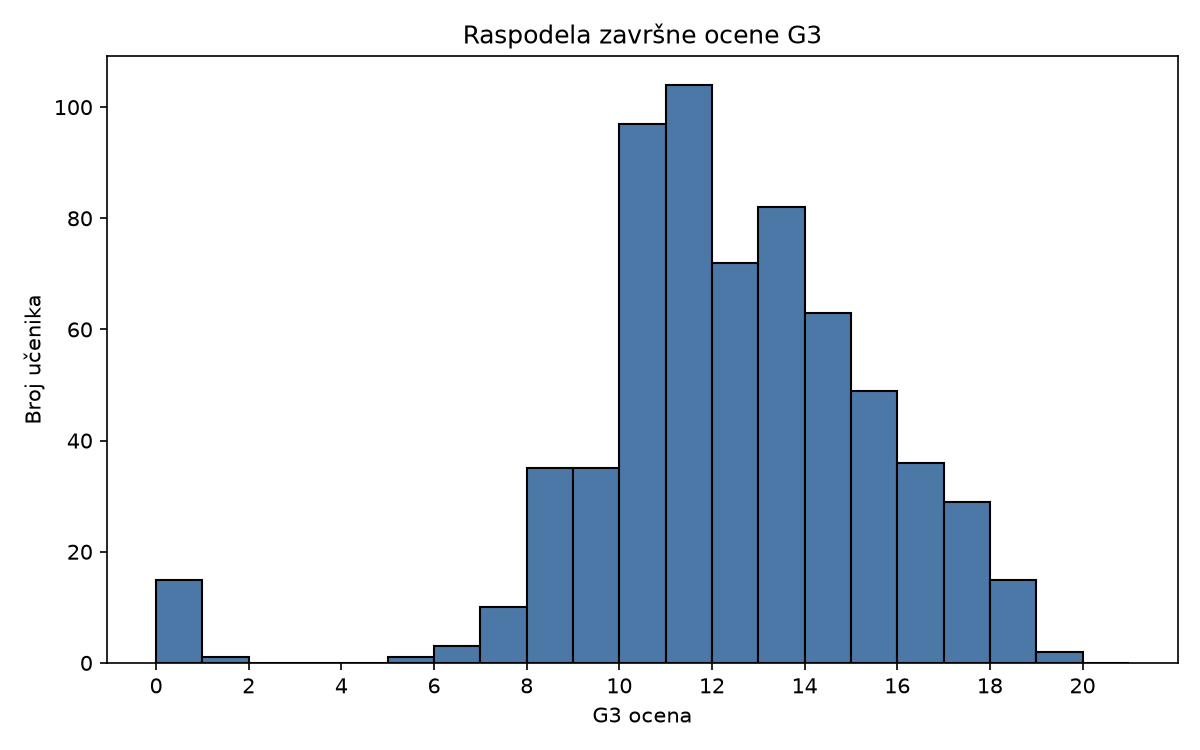

Korelaciona matrica


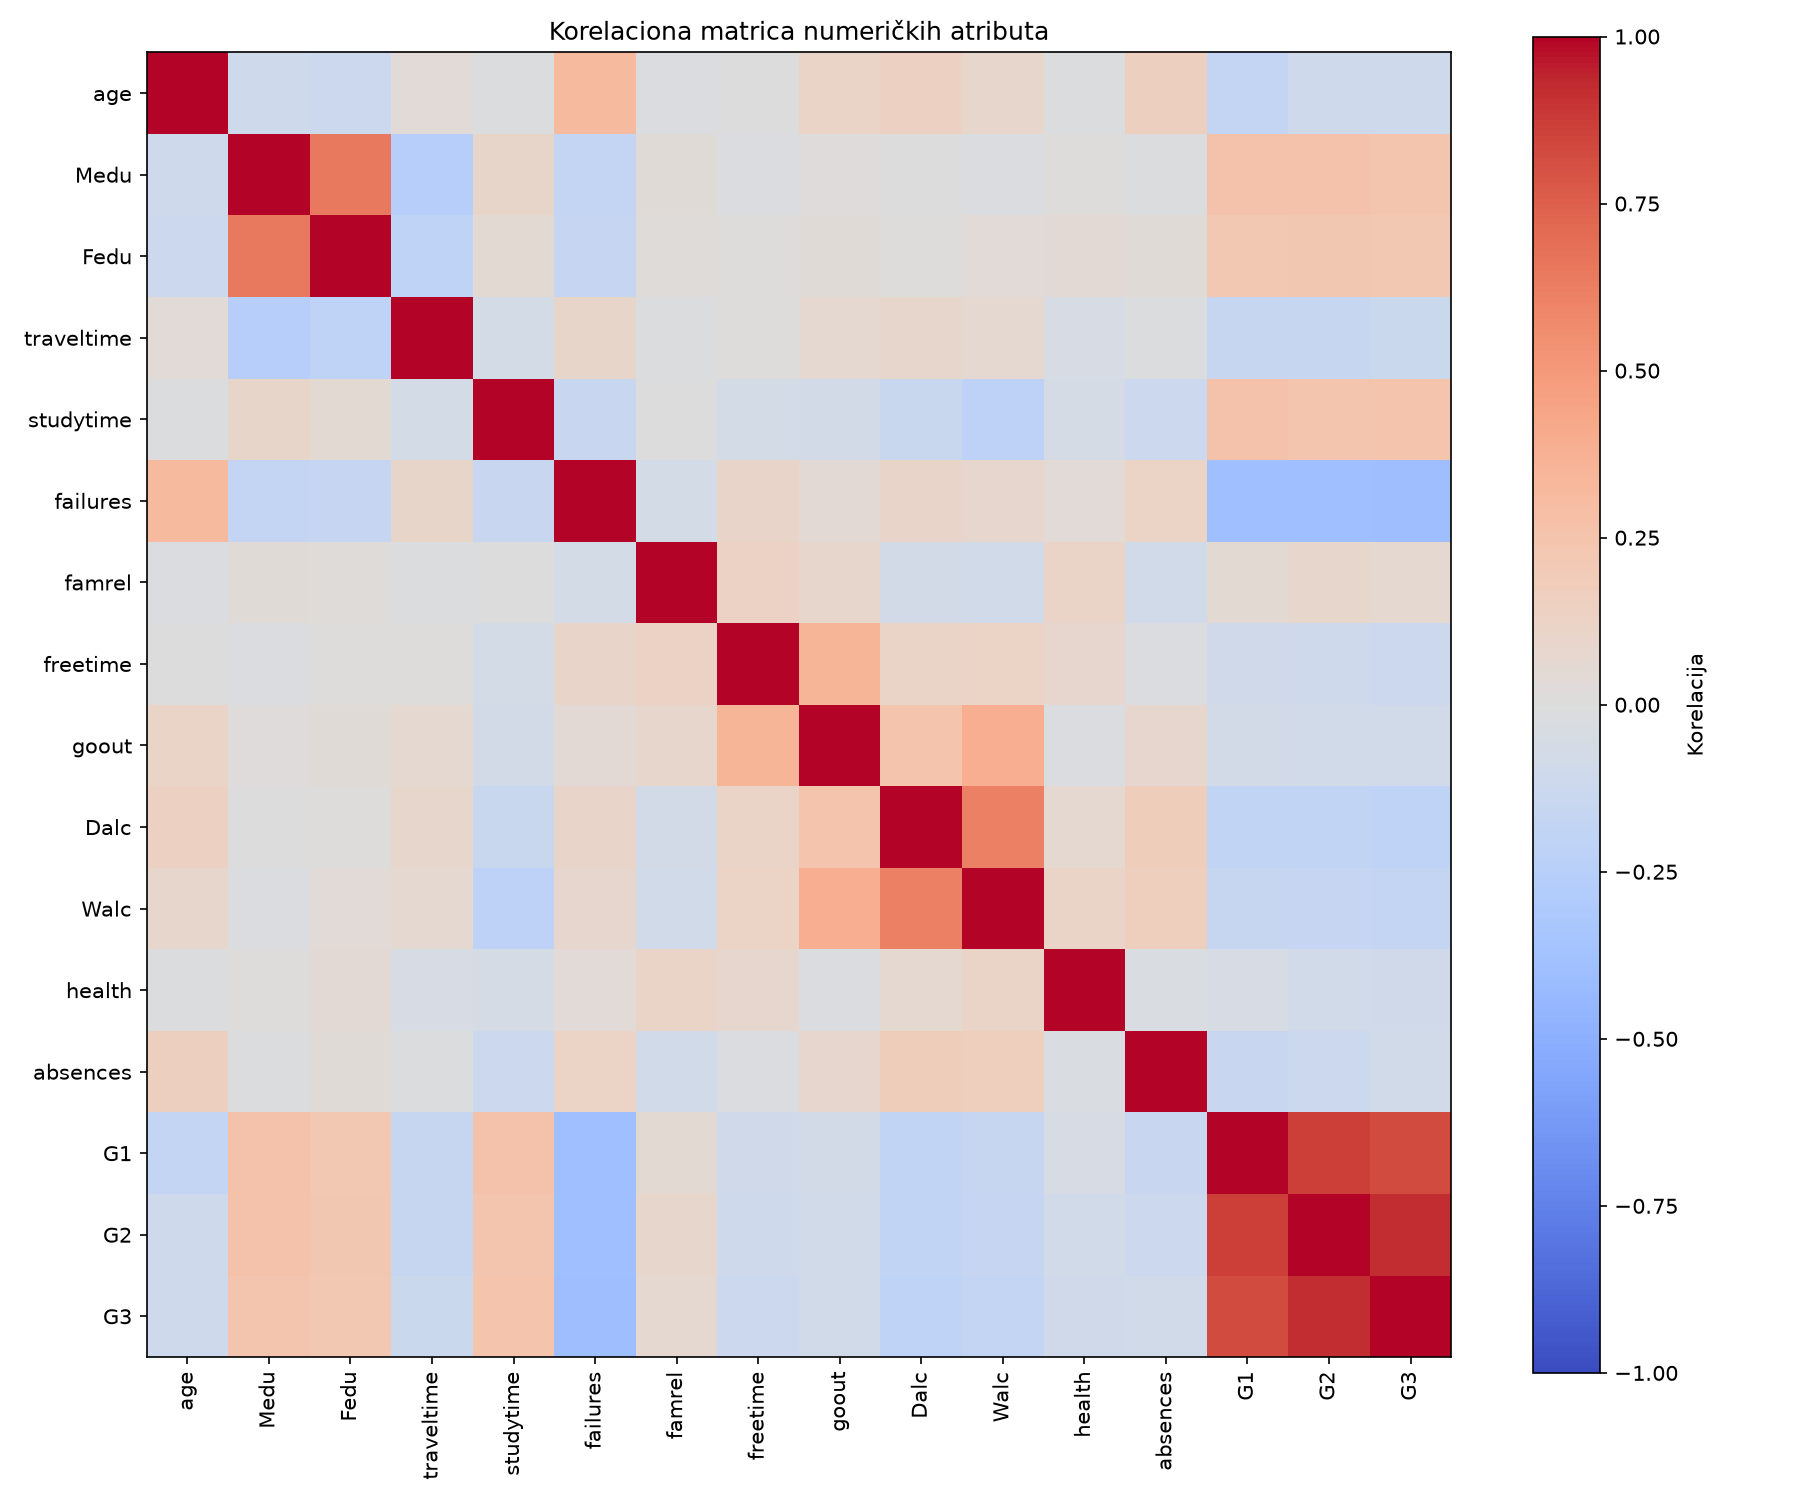

G1 vs G3


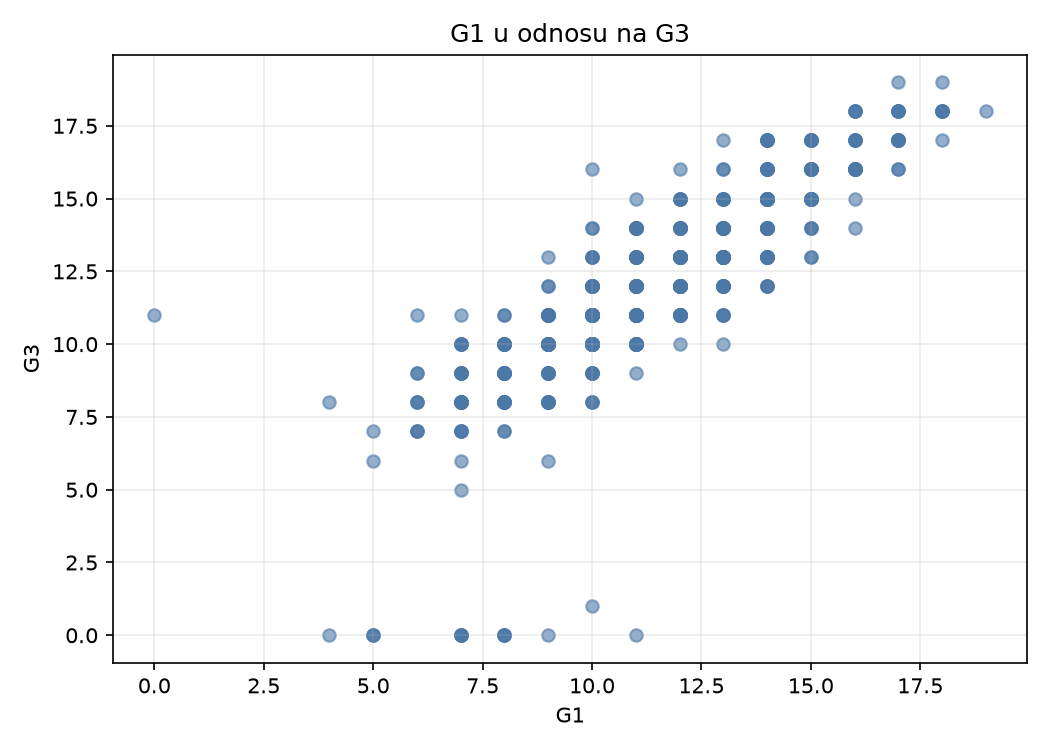

G2 vs G3


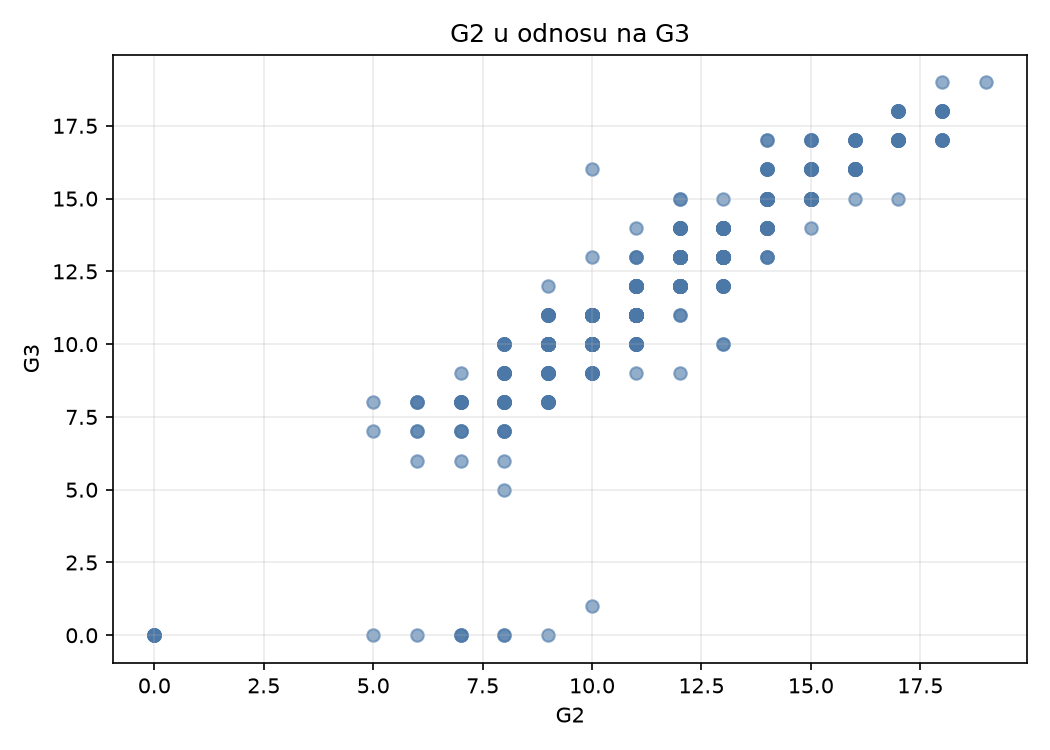

failures vs G3


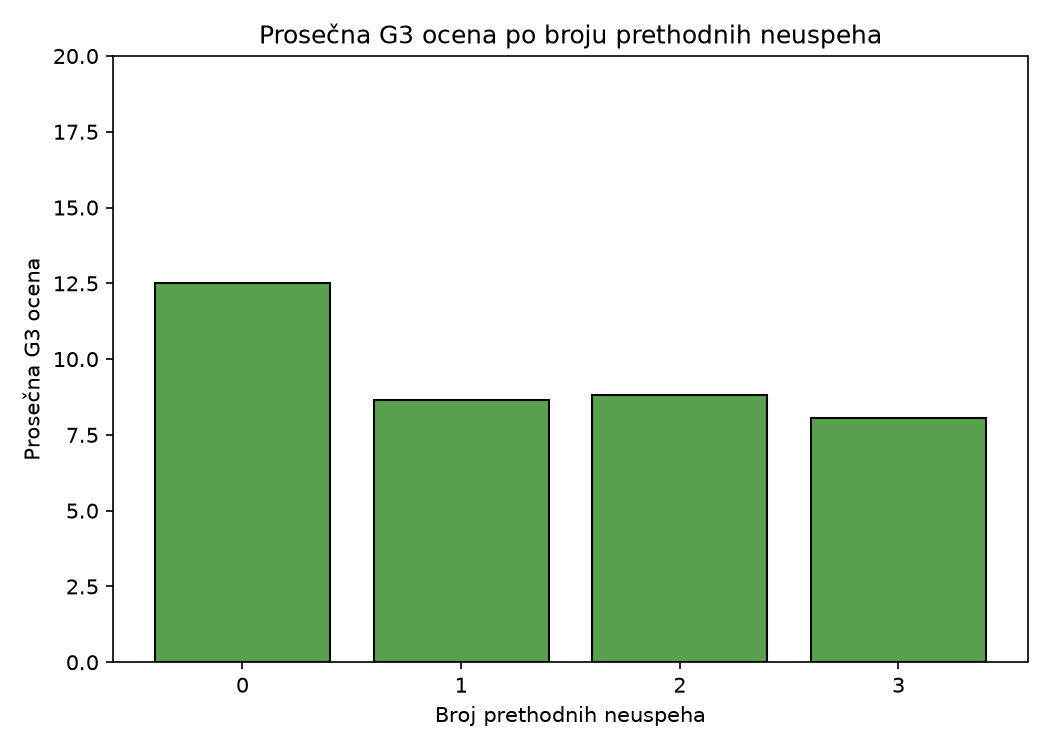

studytime vs G3


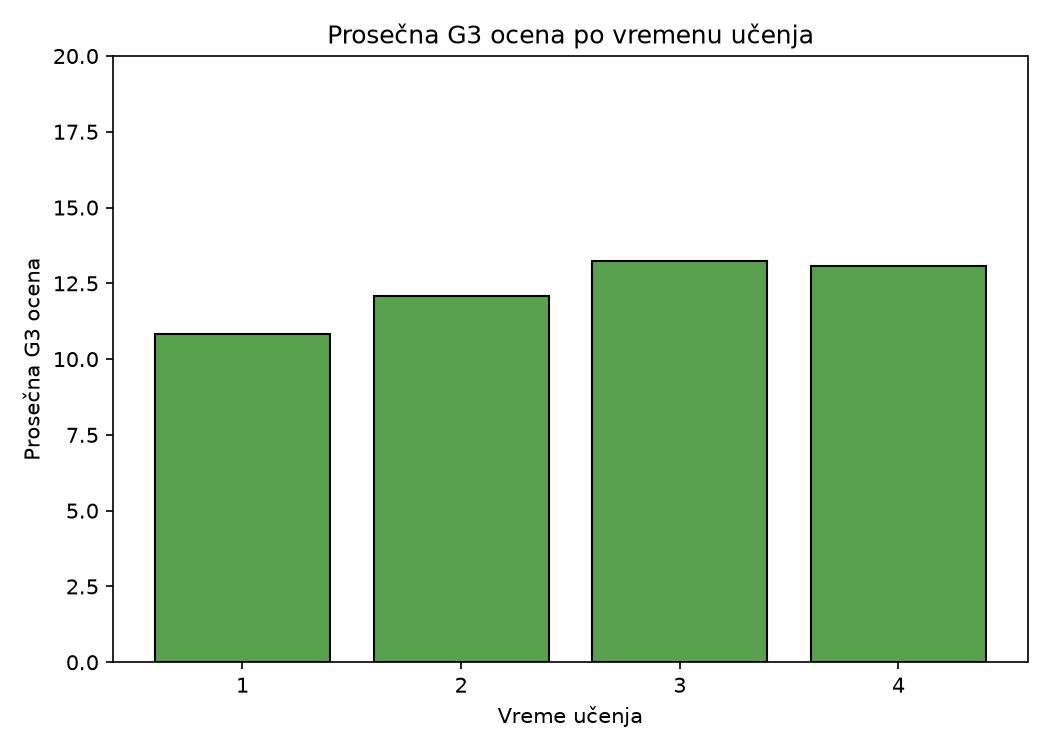

absences raspodela


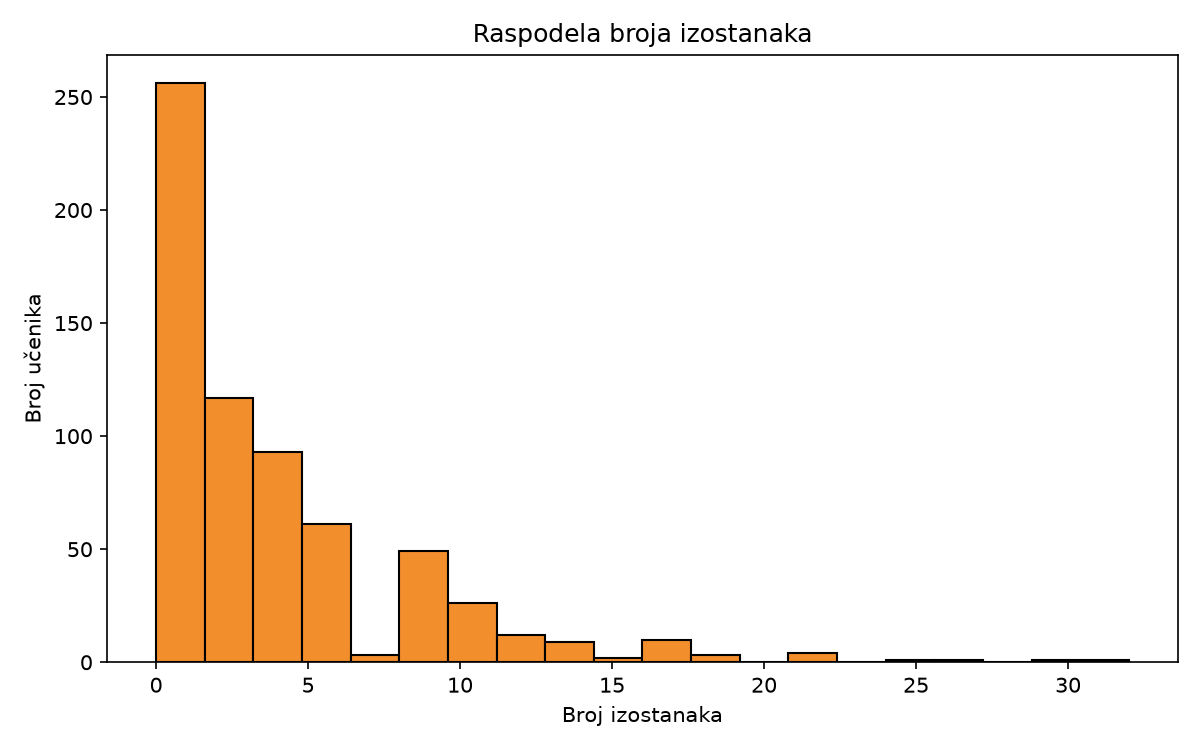

In [7]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "student-por.csv"
STEP01_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step01_data_preparation"
STEP02_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step02_eda"
STEP02_GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "step02_eda"
STEP03_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step03_data_split"
STEP04_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step04_model_training"
STEP05_GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "step05_model_comparison"
STEP06_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step06_hyperparameter_tuning"

from IPython.display import Image, display

graph_paths = [
    ("Raspodela G3", STEP02_GRAPHS_DIR / "g3_distribution.png"),
    ("Korelaciona matrica", STEP02_GRAPHS_DIR / "numeric_correlation_matrix.png"),
    ("G1 vs G3", STEP02_GRAPHS_DIR / "g1_vs_g3.png"),
    ("G2 vs G3", STEP02_GRAPHS_DIR / "g2_vs_g3.png"),
    ("failures vs G3", STEP02_GRAPHS_DIR / "failures_vs_g3.png"),
    ("studytime vs G3", STEP02_GRAPHS_DIR / "studytime_vs_g3.png"),
    ("absences raspodela", STEP02_GRAPHS_DIR / "absences_distribution.png"),
]

for title, graph_path in graph_paths:
    print(title)
    display(Image(filename=str(graph_path)))


## Objasnjenje najvaznijih delova koda iz `step02_eda.py`

Ova sekcija izdvaja delove `step02_eda.py` koje je najvaznije razumeti za odbranu. Cilj nije da se prepisuje ceo fajl, vec da se jasno objasni sta EDA korak radi i zasto.

### 1. Definisanje putanja za podatke, grafike i logove

Na pocetku se definisu putanje do dataset-a, foldera za grafike i foldera za CSV izvestaje:

```python
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "student-por.csv"
GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "step02_eda"
LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step02_eda"
```

Ovo omogucava da se svi rezultati EDA koraka cuvaju na jednom predvidljivom mestu: grafici u `data/graphs/step02_eda/`, a tekstualni izvestaj u `data/logs/step02_eda/`.

### 2. Ucitavanje dataset-a

Kao i u prvom koraku, podaci se ucitavaju iz `student-por.csv` pomocu pandas biblioteke:

```python
df = pd.read_csv(DATA_PATH)
```

EDA ne menja dataset, vec ga analizira kroz statistike, korelacije i grafike.

### 3. Raspodela ciljne promenljive G3

Funkcija `create_g3_distribution_graph` pravi histogram zavrsne ocene G3. Ovaj grafik pokazuje koliko ucenika ima koju zavrsnu ocenu na skali 0-20.

Ovo je vazno jer pre modelovanja treba razumeti da li je ciljna promenljiva ravnomerno rasporedjena, da li postoje ekstremne vrednosti i koliko ima slucajeva sa G3 = 0.

### 4. Korelaciona matrica numerickih atributa

U skripti se izdvajaju numericke kolone i racuna njihova korelacija:

```python
numeric_df = df.select_dtypes(include="number")
correlation_matrix = numeric_df.corr()
```

Na osnovu te matrice pravi se `numeric_correlation_matrix.png`. Posebno se posmatraju korelacije G1-G3 i G2-G3, jer G1 i G2 predstavljaju prethodne ocene i ocekivano su najjace povezane sa zavrsnom ocenom.

### 5. Pojedinacni grafici za vazne atribute

Skripta pravi posebne grafike za:

- odnos `G1` i `G3`,
- odnos `G2` i `G3`,
- prosecnu G3 ocenu po broju prethodnih neuspeha (`failures`),
- prosecnu G3 ocenu po vremenu ucenja (`studytime`),
- raspodelu broja izostanaka (`absences`).

Ovi grafici pomazu da se korelacije i potencijalne anomalije ne vide samo kroz brojeve, vec i vizuelno.

### 6. Pravljenje `eda_report.csv`

Funkcija `create_eda_report` pravi kratak CSV izvestaj sa najvaznijim EDA nalazima: broj ucenika, minimalnu, maksimalnu i prosecnu G3 ocenu, broj i procenat ucenika sa G3 = 0, kljucne korelacije i najjacu korelaciju sa G3.

Na kraju se u izvestaj dodaje i zakljucak EDA analize. Time se rezultati drugog koraka mogu brzo procitati bez ponovnog tumacenja svih grafika.

### Kako bih ovo objasnio na odbrani?

U drugom koraku sam uradio eksplorativnu analizu podataka da bih razumeo kako su atributi povezani sa zavrsnom ocenom G3. Posebno sam gledao korelacije izmedju prethodnih ocena G1 i G2 i ciljne promenljive, jer one najvise uticu na kasnije modelovanje. Takodje sam proverio raspodelu ocene G3, broj izostanaka i slucajeve sa G3 = 0. Na osnovu ovih nalaza nisam brisao te vrednosti, jer mogu biti stvarni i vazni za model. Ovaj korak mi je pomogao da vidim koji atributi nose najvise informacija i da kasnije smisleno poredim modele sa i bez G1 i G2.

## Zakljucak posle drugog koraka

Posle drugog koraka imamo osnovnu EDA analizu dataset-a. Napravljeni su grafici za raspodelu G3, korelacije numerickih atributa, odnos G1/G2 sa G3, kao i pregled atributa `failures`, `studytime` i `absences`.

Prema trenutnom `eda_report.csv`, G1 i G2 su najjace povezani sa zavrsnom ocenom G3. Zbog toga je opravdano da kasnije poredimo modele sa G1 i G2 i modele bez G1 i G2.

Vrednosti G3 = 0 i vece vrednosti `absences` se za sada ne brisu. U ovom koraku ih samo evidentiramo, jer mogu predstavljati realne slucajeve u dataset-u. Odluka o eventualnoj dodatnoj obradi dolazi kasnije, kada se bude radilo modelovanje i evaluacija.

# Step 03 - Podela podataka na train, validation i test skup

U trećem koraku projekta urađena je podela podataka kroz fajl `src/step03_data_split.py`. Dataset se i dalje učitava iz originalnog fajla `data/raw/student-por.csv`, ali se sada redovi dele na tri odvojena skupa: train, validation i test.

Podela je napravljena jednom, a zatim se isti redovi koriste u oba scenarija modelovanja: `with_G1_G2` i `without_G1_G2`. Ovo je važno zato što poređenje modela postaje fer - razlika između scenarija nije u tome koji učenici su završili u train/test skupu, već samo u tome da li model vidi atribute `G1` i `G2`.

Korišćena podela je približno 70/15/15:

- train skup služi za obučavanje modela,
- validation skup služi za poređenje modela i kasnije izbor hiperparametara,
- test skup služi kao odvojena provera rezultata.

Splitovani fajlovi se čuvaju u `data/split/`, a izveštaj o podeli u `data/logs/step03_data_split/split_report.csv`.


## Split izveštaj

Ova ćelija prikazuje postojeći `split_report.csv`. U njemu se vidi koliko redova ima svaki skup i gde su splitovani fajlovi sačuvani.


In [ ]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "student-por.csv"
STEP01_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step01_data_preparation"
STEP02_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step02_eda"
STEP02_GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "step02_eda"
STEP03_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step03_data_split"
STEP04_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step04_model_training"
STEP05_GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "step05_model_comparison"
STEP06_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step06_hyperparameter_tuning"

split_report = pd.read_csv(STEP03_LOGS_DIR / "split_report.csv")
split_report


## Objašnjenje najvažnijih delova koda iz `step03_data_split.py`

Najvažnija stvar u ovom koraku je da se podela radi samo jednom. Prvo se izdvaja train skup od oko 70%, a preostalih 30% se zatim deli na validation i test skup. Korišćen je `random_state = 42` da bi podela bila ponovljiva, odnosno da se pri svakom pokretanju dobiju isti redovi u istim skupovima.

Ne prave se posebni splitovi za `with_G1_G2` i `without_G1_G2`. Umesto toga, oba scenarija kasnije koriste iste train, validation i test redove, a razlikuju se samo po kolonama koje model dobija kao ulaz.

U ovom koraku nema enkodiranja, skaliranja niti treniranja modela. Splitovani CSV fajlovi i dalje sadrže originalne vrednosti iz raw dataset-a. Preprocessing se radi kasnije unutar `Pipeline` objekta, da ne bi došlo do curenja informacija iz validation/test skupa u train skup.


## Zaključak posle trećeg koraka

Posle trećeg koraka imamo jasnu i ponovljivu podelu podataka. Train skup ima 454 reda, validation skup 97 redova, a test skup 98 redova. Time je pripremljena osnova za korektno treniranje i poređenje modela.


# Step 04 - Treniranje i poređenje osnovnih modela

U četvrtom koraku urađeno je prvo modelovanje kroz fajl `src/step04_model_training.py`. Ovaj korak koristi splitovane skupove iz Step 03 i poredi dogovorene modele kroz dva scenarija.

Scenariji su:

- `with_G1_G2`: model koristi sve ulazne atribute osim `G3`, pa su `G1` i `G2` uključeni,
- `without_G1_G2`: model koristi sve ulazne atribute osim `G1`, `G2` i `G3`.

Modeli koji se treniraju su:

- `DummyRegressor` kao baseline,
- `Ridge Regression`,
- `RandomForestRegressor`.

Za svaki model se pravi `Pipeline`. U pipeline-u se prvo radi preprocessing, pa tek onda treniranje modela. Numerički atributi se skaliraju pomoću `StandardScaler`, a kategorijski atributi se pretvaraju u numerički oblik pomoću `OneHotEncoder(handle_unknown="ignore")`.


## Default hiperparametri korišćeni u osnovnim modelima

U Step 04 modeli su trenirani u osnovnoj verziji, bez podešavanja hiperparametara. To znači da ovaj korak služi kao početno poređenje modela pre tuninga. Kasnije ćemo probati različite vrednosti hiperparametara i proveriti da li se rezultati mogu poboljšati.

Korišćeni su sledeći modeli i parametri:

- `DummyRegressor(strategy=mean)` - baseline model koji uvek predviđa prosečnu vrednost `G3` iz train skupa. On ne uči složene veze iz podataka, već služi kao minimalni rezultat koji ozbiljniji modeli treba da nadmaše.
- `Ridge()` - linearni regresioni model sa regularizacijom. Kada se ne navede drugačije, koristi se podrazumevana vrednost `alpha=1.0`. Parametar `alpha` kontroliše jačinu regularizacije: veća vrednost više ograničava koeficijente modela, a manja vrednost dopušta fleksibilniji model.
- `RandomForestRegressor(n_estimators=100, random_state=42)` - model zasnovan na ansamblu više decision tree modela. Parametar `n_estimators=100` znači da se koristi 100 stabala. `random_state=42` obezbeđuje da rezultati budu ponovljivi pri svakom pokretanju. Ostali parametri, kao što su `max_depth` i `min_samples_leaf`, za sada ostaju na default vrednostima.

Važno je da se ovi rezultati ne posmatraju kao finalni najbolji mogući rezultati. Oni predstavljaju osnovnu tačku poređenja, a naredni korak je hyperparameter tuning, gde ćemo sistematski probati više vrednosti za `alpha`, `n_estimators`, `max_depth` i `min_samples_leaf`.


## Korišćene metrike

Za evaluaciju se koriste tri regresione metrike:

- **MAE** (*Mean Absolute Error*) pokazuje prosečnu apsolutnu grešku modela. Ako je MAE 0.82, to znači da model u proseku greši za oko 0.82 ocene. Manja vrednost je bolja.
- **RMSE** (*Root Mean Squared Error*) takođe meri grešku, ali jače kažnjava veće promašaje. Manja vrednost je bolja.
- **R2** pokazuje koliki deo varijacije ciljne promenljive model objašnjava. Vrednost bliža 1 je bolja, vrednost oko 0 znači da model nije bolji od jednostavnog proseka, a negativna vrednost znači da je lošiji od baseline pristupa.

Validation metrike se koriste za poređenje modela, dok test metrike služe kao dodatna provera na odvojenom skupu podataka.


## Model comparison izveštaj

Ova ćelija učitava postojeći `model_comparison_report.csv`. U njemu su prikazani rezultati za svaki model i oba scenarija, posebno za validation i test skup.


In [8]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "student-por.csv"
STEP01_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step01_data_preparation"
STEP02_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step02_eda"
STEP02_GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "step02_eda"
STEP03_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step03_data_split"
STEP04_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step04_model_training"
STEP05_GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "step05_model_comparison"
STEP06_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step06_hyperparameter_tuning"

model_comparison_report = pd.read_csv(STEP04_LOGS_DIR / "model_comparison_report.csv")
model_comparison_report


,scenario,model,number_of_features,numeric_features,categorical_features,train_rows,validation_rows,test_rows,validation_MAE,validation_RMSE,validation_R2,test_MAE,test_RMSE,test_R2
0,with_G1_G2,DummyRegressor,32,15,17,454,97,98,2.3008,3.1360,-0.0004,2.5932,3.5229,-0.0291
1,with_G1_G2,Ridge Regression,32,15,17,454,97,98,0.7686,1.0555,0.8867,0.8204,1.3314,0.8530
2,with_G1_G2,RandomForestRegressor,32,15,17,454,97,98,0.7058,0.9862,0.9011,0.8556,1.3905,0.8397
3,without_G1_G2,DummyRegressor,30,13,17,454,97,98,2.3008,3.1360,-0.0004,2.5932,3.5229,-0.0291
4,without_G1_G2,Ridge Regression,30,13,17,454,97,98,2.1183,2.8668,0.1639,2.3377,3.0243,0.2416
5,without_G1_G2,RandomForestRegressor,30,13,17,454,97,98,2.0923,2.7779,0.2150,2.1971,2.9105,0.2976


## Tumačenje rezultata Step 04

Rezultati pokazuju jasnu razliku između scenarija sa `G1/G2` i scenarija bez `G1/G2`. Kada se koriste prethodne ocene, modeli imaju znatno bolje rezultate. To je očekivano jer su `G1` i posebno `G2` u EDA analizi pokazali veoma jaku pozitivnu korelaciju sa završnom ocenom `G3`.

U scenariju `with_G1_G2`, `Ridge Regression` i `RandomForestRegressor` su mnogo bolji od baseline modela. Na validation skupu Random Forest ima najbolji R2 rezultat, dok je Ridge vrlo blizu. Na test skupu Ridge ima malo bolji R2 od Random Forest modela, što znači da linearni model dobro koristi informaciju koju nose prethodne ocene.

U scenariju `without_G1_G2`, rezultati su dosta slabiji. To ne znači da je model pogrešno napravljen, već da bez prethodnih ocena model nema najjače informacije za predikciju `G3`. Ipak, Ridge i Random Forest su i dalje bolji od `DummyRegressor` baseline modela, pa ostali atributi nose određeni signal, samo mnogo slabiji od `G1` i `G2`.

Glavni zaključak je da su modeli sa `G1/G2` bolji za preciznu predikciju, dok je scenario bez `G1/G2` praktično važan jer pokazuje koliko se završna ocena može predvideti bez prethodnih ocena.


## Objašnjenje najvažnijih delova koda iz `step04_model_training.py`

Fajl `step04_model_training.py` prvo učitava `train.csv`, `validation.csv` i `test.csv`. Zatim definiše scenarije tako što za `with_G1_G2` izbacuje samo `G3`, a za `without_G1_G2` izbacuje `G1`, `G2` i `G3`.

Nakon toga se atributi dele na numeričke i kategorijske. Numerički atributi prolaze kroz `StandardScaler`, a kategorijski kroz `OneHotEncoder`. Ove transformacije se nalaze unutar `Pipeline` objekta, što znači da se preprocessing uči samo na train skupu, a zatim se ista naučena transformacija primenjuje na validation i test skup.

Trenutno nisu podešavani hiperparametri. Korišćene su osnovne verzije modela: `DummyRegressor(strategy="mean")`, `Ridge()` i `RandomForestRegressor(n_estimators=100, random_state=42)`. Podešavanje hiperparametara dolazi u narednom koraku.


# Step 05 - Grafičko poređenje modela

U petom koraku napravljeni su grafici za lakše poređenje rezultata iz Step 04. Fajl `src/step05_model_comparison_graphs.py` ne trenira modele ponovo, već samo čita postojeći `model_comparison_report.csv` i na osnovu njega pravi grafike.

Grafici se čuvaju u `data/graphs/step05_model_comparison/`:

- `validation_metrics_comparison.png`,
- `test_metrics_comparison.png`.

Na svakom grafiku prikazane su metrike MAE, RMSE i R2 za oba scenarija i sva tri modela. Ovo pomaže da se razlika između modela vidi odmah, bez čitanja cele CSV tabele.


## Model comparison grafici

Sledeća ćelija prikazuje već sačuvane PNG grafike iz Step 05. Ne generiše se ništa novo u notebook-u.


Validation metrike


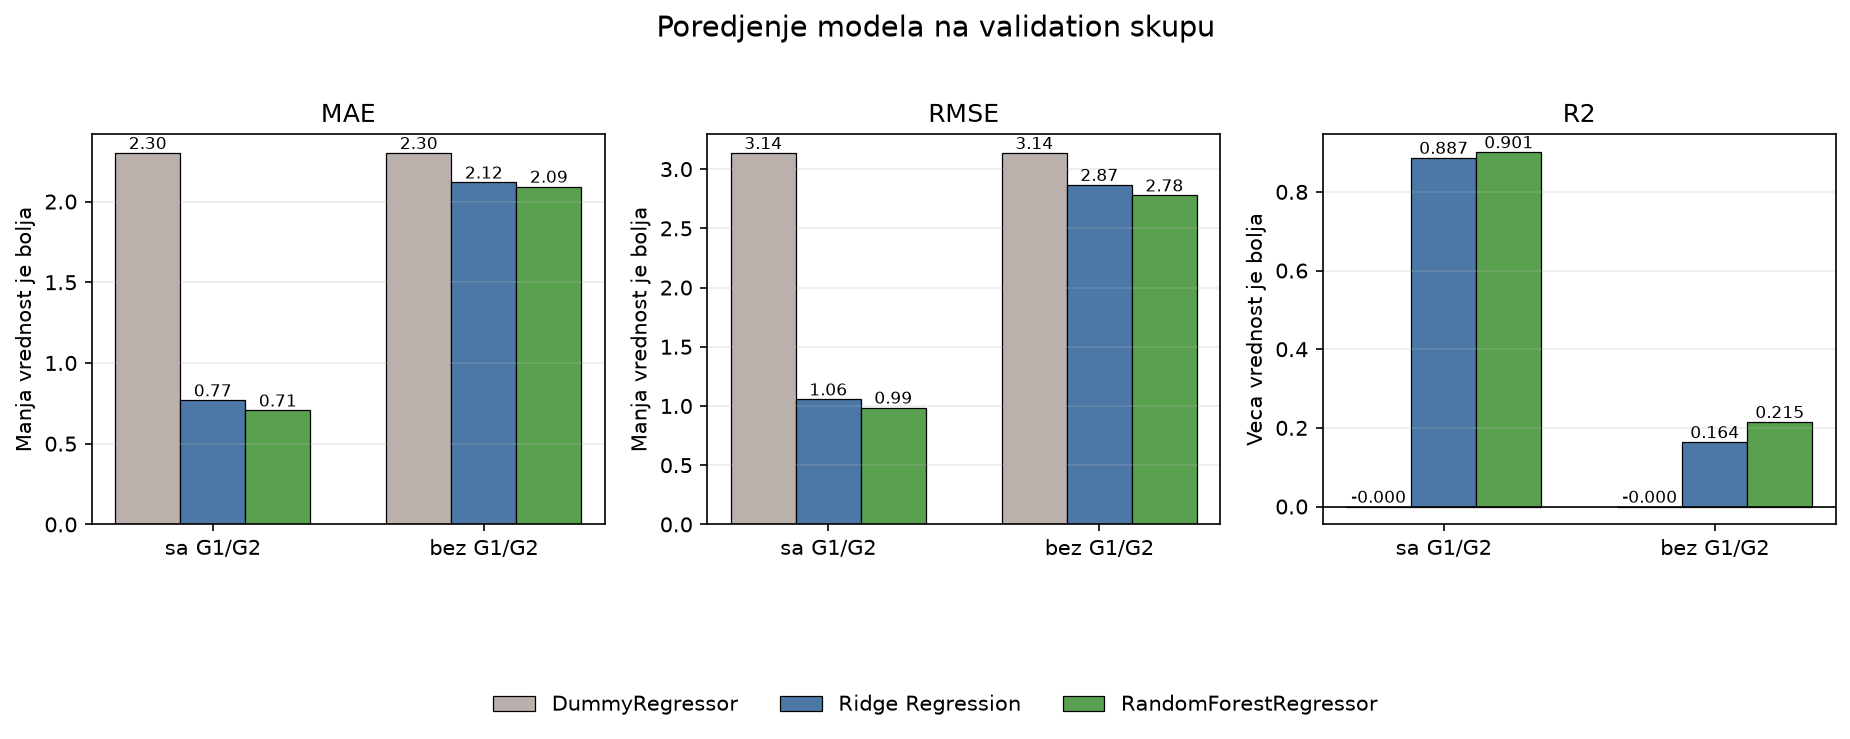

Test metrike


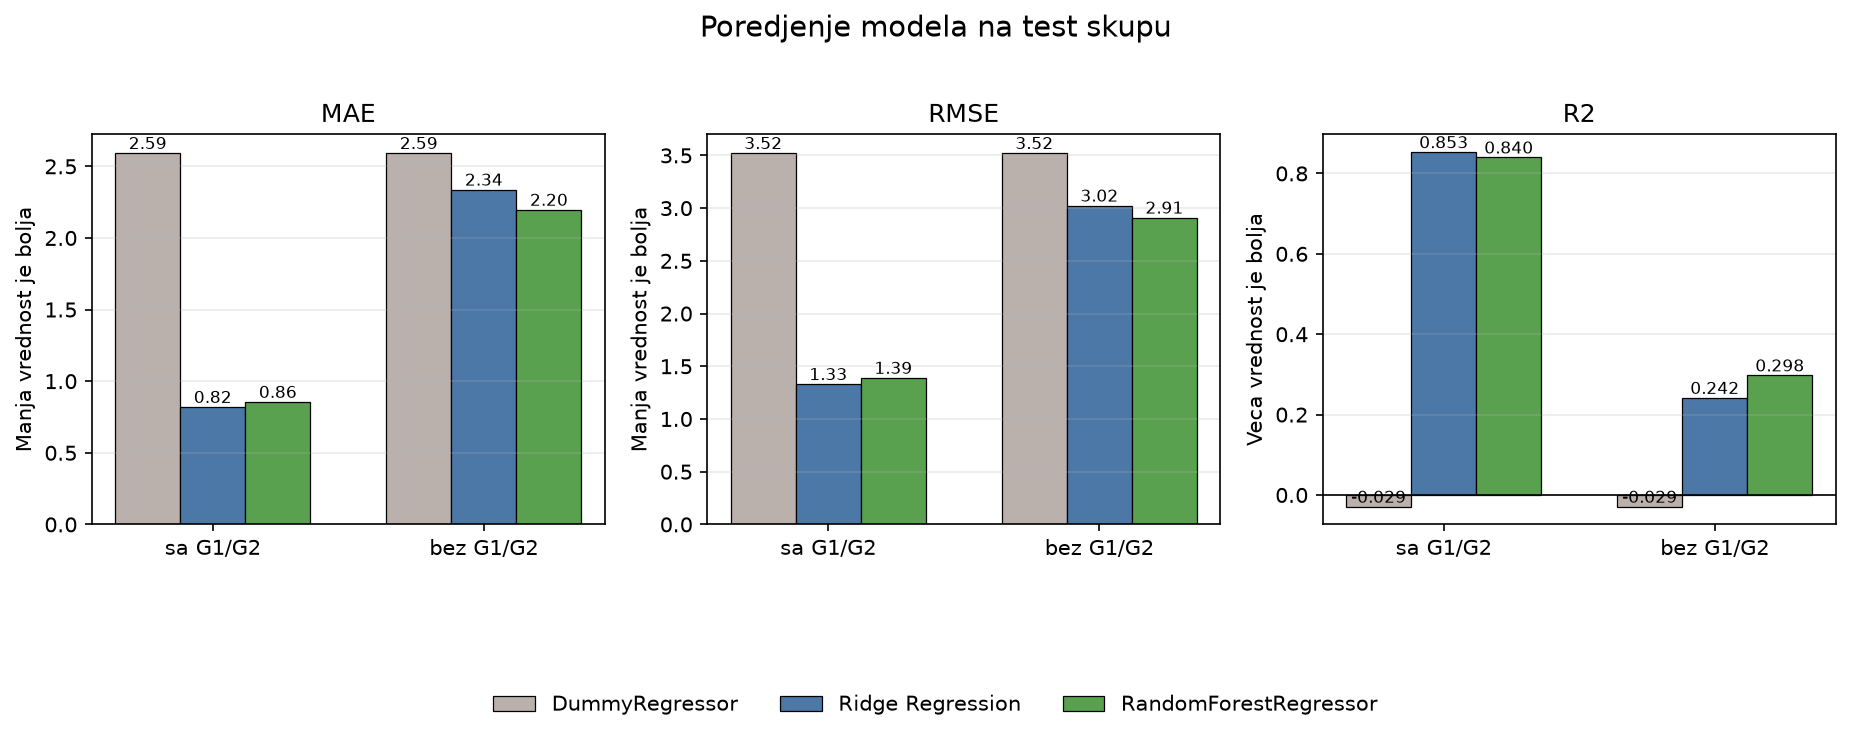

In [7]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "student-por.csv"
STEP01_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step01_data_preparation"
STEP02_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step02_eda"
STEP02_GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "step02_eda"
STEP03_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step03_data_split"
STEP04_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step04_model_training"
STEP05_GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "step05_model_comparison"
STEP06_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step06_hyperparameter_tuning"

from IPython.display import Image, display

step05_graph_paths = [
    ("Validation metrike", STEP05_GRAPHS_DIR / "validation_metrics_comparison.png"),
    ("Test metrike", STEP05_GRAPHS_DIR / "test_metrics_comparison.png"),
]

for title, graph_path in step05_graph_paths:
    print(title)
    display(Image(filename=str(graph_path)))


## Zaključak posle petog koraka

Grafici potvrđuju isti zaključak kao i CSV report: scenario sa `G1/G2` daje mnogo bolje rezultate, dok je scenario bez `G1/G2` slabiji ali praktično važan. Baseline model ima R2 oko nule ili ispod nule, što znači da samo predviđanje prosečne ocene nije dovoljno dobro.

Kod modela sa `G1/G2`, greške su male u odnosu na skalu ocena 0-20. Kod modela bez `G1/G2`, greške su veće jer model nema prethodne ocene koje su najjače povezane sa `G3`. Ovo je važan rezultat za dokumentaciju: prethodne ocene značajno poboljšavaju predikciju, ali model bez njih pokazuje realno ograničenje praktičnog ranog predviđanja.

Sledeći korak pre feature importance analize je podešavanje hiperparametara. Tuning ima najviše smisla za `Ridge Regression` i `RandomForestRegressor`, dok `DummyRegressor` ostaje baseline model.


# Step 06 - Podešavanje hiperparametara

U šestom koraku urađeno je podešavanje hiperparametara kroz fajl `src/step06_hyperparameter_tuning.py`. Ovaj korak dolazi nakon osnovnog poređenja modela, jer prvo treba imati početne rezultate sa default parametrima, a tek onda proveriti da li se boljim izborom hiperparametara rezultati mogu poboljšati.

U ovom koraku se ne tunira `DummyRegressor`, jer je on baseline model. Podešavanje se radi samo za `Ridge Regression` i `RandomForestRegressor`.

Korišćena je ručna grid search logika preko već napravljenih skupova:

- svaka kombinacija hiperparametara se trenira na train skupu,
- svaka kombinacija se ocenjuje na validation skupu,
- najbolja kombinacija se bira po najmanjoj vrednosti `validation_RMSE`,
- test metrike se računaju samo za izabrane najbolje kombinacije.

Ovakav postupak je važan zato što test skup ne treba koristiti za biranje hiperparametara. Test skup treba da ostane završna provera modela koji je već izabran na osnovu validation rezultata.


## Grid hiperparametara

Za `Ridge Regression` isprobane su različite vrednosti parametra `alpha`: 0.01, 0.1, 1.0, 10.0 i 100.0. Parametar `alpha` kontroliše jačinu regularizacije. Veći `alpha` više ograničava koeficijente modela, dok manji `alpha` dozvoljava fleksibilniji model.

Za `RandomForestRegressor` isprobane su kombinacije parametara:

- `n_estimators`: 100 i 200,
- `max_depth`: None, 5 i 10,
- `min_samples_leaf`: 1, 2 i 5.

`n_estimators` označava broj stabala u šumi. `max_depth` ograničava maksimalnu dubinu stabala i može pomoći da se model ne prilagodi previše train skupu. `min_samples_leaf` određuje minimalan broj uzoraka u listu stabla i takođe može smanjiti overfitting.


## Tuning details report

Ovaj izveštaj sadrži sve isprobane kombinacije hiperparametara. U njemu se čuvaju samo validation metrike, jer se izbor hiperparametara radi na validation skupu. Kolona `is_best` označava najbolju kombinaciju za svaki scenario i model.


In [6]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "student-por.csv"
STEP01_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step01_data_preparation"
STEP02_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step02_eda"
STEP02_GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "step02_eda"
STEP03_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step03_data_split"
STEP04_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step04_model_training"
STEP05_GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "step05_model_comparison"
STEP06_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step06_hyperparameter_tuning"

tuning_details = pd.read_csv(STEP06_LOGS_DIR / "hyperparameter_tuning_details.csv")
tuning_details


,scenario,model,parameters,number_of_features,numeric_features,categorical_features,train_rows,validation_rows,validation_MAE,validation_RMSE,validation_R2,is_best
0,with_G1_G2,Ridge Regression,alpha=0.01,32,15,17,454,97,0.7719,1.0577,0.8862,Ne
1,with_G1_G2,Ridge Regression,alpha=0.1,32,15,17,454,97,0.7716,1.0575,0.8862,Ne
2,with_G1_G2,Ridge Regression,alpha=1.0,32,15,17,454,97,0.7686,1.0555,0.8867,Ne
3,with_G1_G2,Ridge Regression,alpha=10.0,32,15,17,454,97,0.7464,1.0457,0.8888,Da
4,with_G1_G2,Ridge Regression,alpha=100.0,32,15,17,454,97,0.7394,1.1264,0.8709,Ne
5,with_G1_G2,RandomForestRegressor,n_estimators=100; max_depth=None; min_samples_...,32,15,17,454,97,0.7058,0.9862,0.9011,Ne
6,with_G1_G2,RandomForestRegressor,n_estimators=100; max_depth=None; min_samples_...,32,15,17,454,97,0.6866,0.9387,0.9104,Ne
7,with_G1_G2,RandomForestRegressor,n_estimators=100; max_depth=None; min_samples_...,32,15,17,454,97,0.6632,0.8926,0.9190,Ne
8,with_G1_G2,RandomForestRegressor,n_estimators=100; max_depth=5; min_samples_leaf=1,32,15,17,454,97,0.6716,0.9536,0.9075,Ne
9,with_G1_G2,RandomForestRegressor,n_estimators=100; max_depth=5; min_samples_leaf=2,32,15,17,454,97,0.6671,0.9225,0.9134,Ne


## Tuning summary report

Ovaj izveštaj prikazuje samo najbolje kombinacije hiperparametara. Za te kombinacije su dodatno izračunate test metrike, jer se test skup koristi tek nakon izbora modela na osnovu validation rezultata.


In [ ]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "student-por.csv"
STEP01_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step01_data_preparation"
STEP02_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step02_eda"
STEP02_GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "step02_eda"
STEP03_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step03_data_split"
STEP04_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step04_model_training"
STEP05_GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "step05_model_comparison"
STEP06_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step06_hyperparameter_tuning"

tuning_summary = pd.read_csv(STEP06_LOGS_DIR / "hyperparameter_tuning_summary.csv")
tuning_summary


## Tumačenje rezultata Step 06

Kod scenarija `with_G1_G2`, najbolji Ridge model koristi `alpha=10.0`, dok najbolji Random Forest koristi `n_estimators=100`, `max_depth=5` i `min_samples_leaf=5`. Random Forest ima najbolji validation rezultat u ovom scenariju, sa nižim RMSE i višim R2 u odnosu na default verziju. To znači da ograničavanje dubine stabala i veći minimalni broj uzoraka u listu pomažu modelu da se manje prilagodi train skupu.

Kod scenarija `without_G1_G2`, najbolji Ridge model koristi `alpha=100.0`, što znači da jača regularizacija pomaže kada model nema najjače prediktore `G1` i `G2`. Najbolji Random Forest u ovom scenariju koristi `n_estimators=100`, `max_depth=10` i `min_samples_leaf=2`. Ipak, rezultati bez `G1/G2` ostaju značajno slabiji od rezultata sa `G1/G2`, što potvrđuje zaključak iz EDA analize da prethodne ocene nose najviše informacija za predikciju `G3`.

Važno je primetiti da bolji validation rezultat ne mora uvek značiti i bolji test rezultat. Na primer, tuning može poboljšati validation RMSE, ali test rezultat može ostati sličan ili čak biti malo slabiji. To se posebno može desiti kod manjih dataset-ova, gde validation i test skup imaju relativno malo redova. Zbog toga tuning rezultate treba tumačiti pažljivo, a ne automatski pretpostaviti da je svaki tuned model bolji u svim uslovima.


## Zaključak posle šestog koraka

Step 06 pokazuje da podešavanje hiperparametara može poboljšati validation rezultate, naročito kod Random Forest modela. Međutim, test rezultati pokazuju da poboljšanje nije uvek jednako snažno na potpuno odvojenom skupu.

Najvažniji metodološki zaključak je da su hiperparametri birani isključivo na validation skupu, dok je test skup korišćen samo za završnu proveru najboljih kombinacija. Time se izbegava biranje modela direktno prema test rezultatu.

Sledeći korak je grafičko poređenje default i tuned modela, kako bi se jasnije videlo gde tuning donosi poboljšanje, a gde su rezultati slični ili slabiji.


# Step 07 - Grafičko poređenje default i tuned modela

U sedmom koraku napravljeni su grafici koji porede osnovne modele iz Step 04 sa tuned modelima iz Step 06. Fajl `src/step07_tuning_graphs.py` ne trenira modele ponovo, već učitava postojeće CSV rezultate i od njih pravi grafički prikaz.

Koriste se dva izvora podataka:

- `data/logs/step04_model_training/model_comparison_report.csv` za default modele,
- `data/logs/step06_hyperparameter_tuning/hyperparameter_tuning_summary.csv` za tuned modele.

Grafici prikazuju samo `Ridge Regression` i `RandomForestRegressor`, jer se `DummyRegressor` ne tunira. Za svaki model porede se default i tuned verzije kroz metrike `MAE`, `RMSE` i `R2`.


## Grafici Step 07

Sledeća ćelija prikazuje već sačuvane grafike iz `data/graphs/step07_tuning_graphs/`. Ne generiše se ništa novo u notebook-u.


Default vs tuned - validation


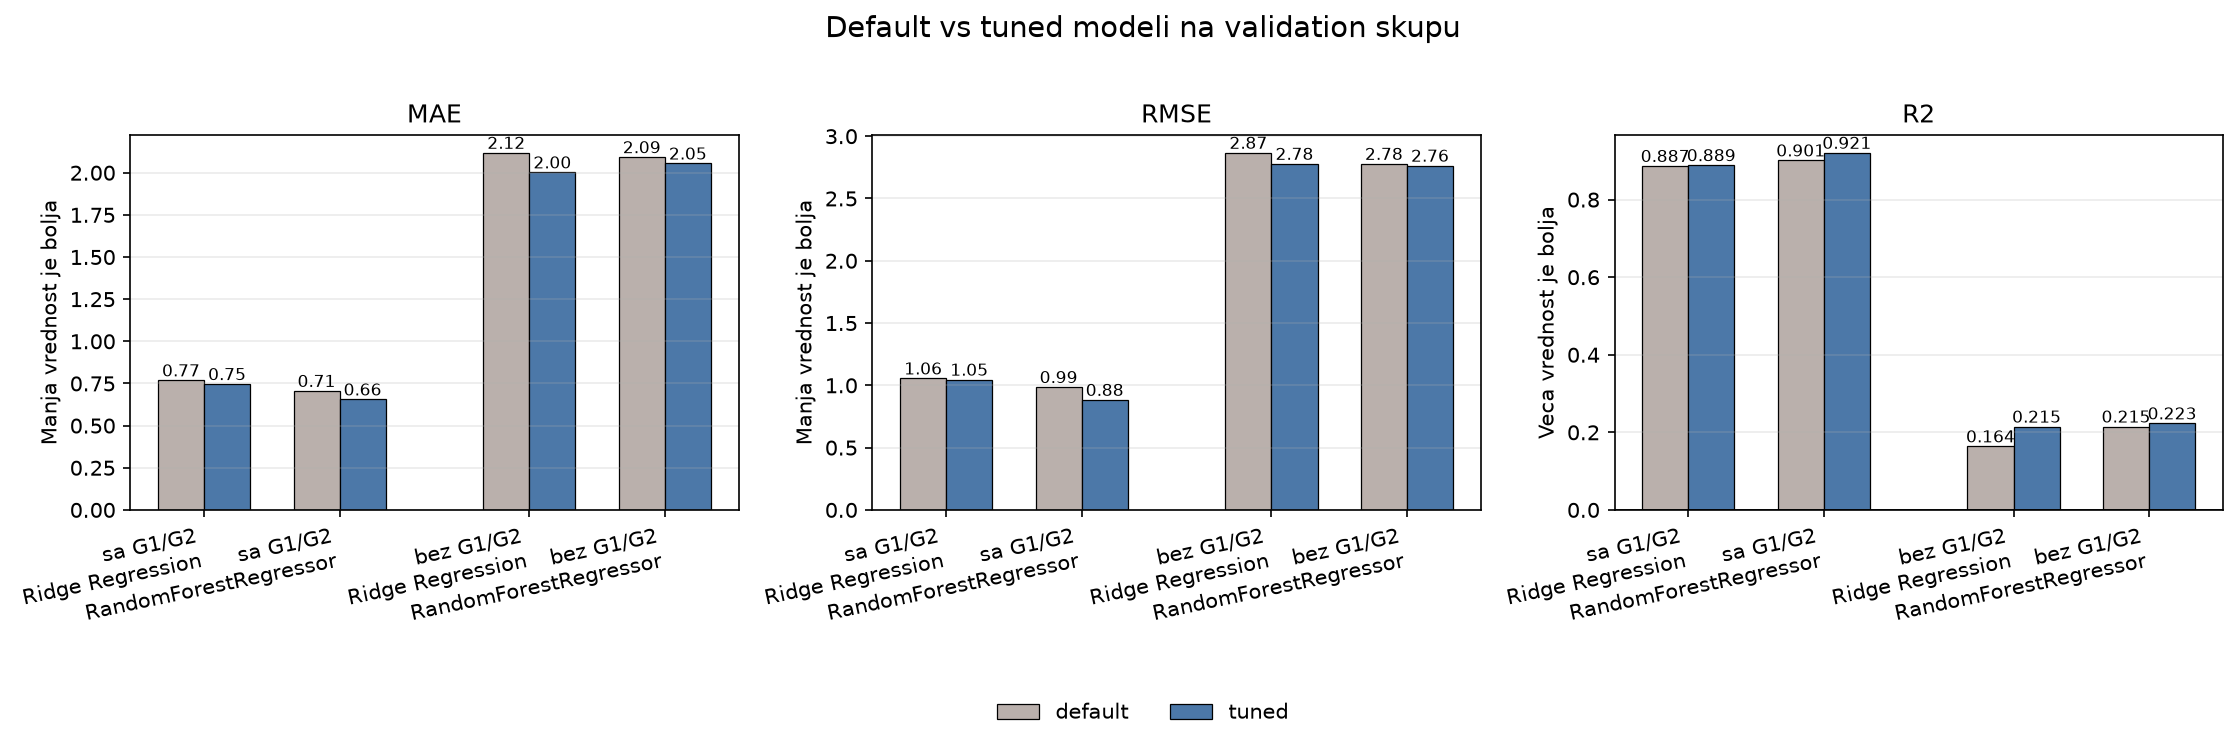

Default vs tuned - test


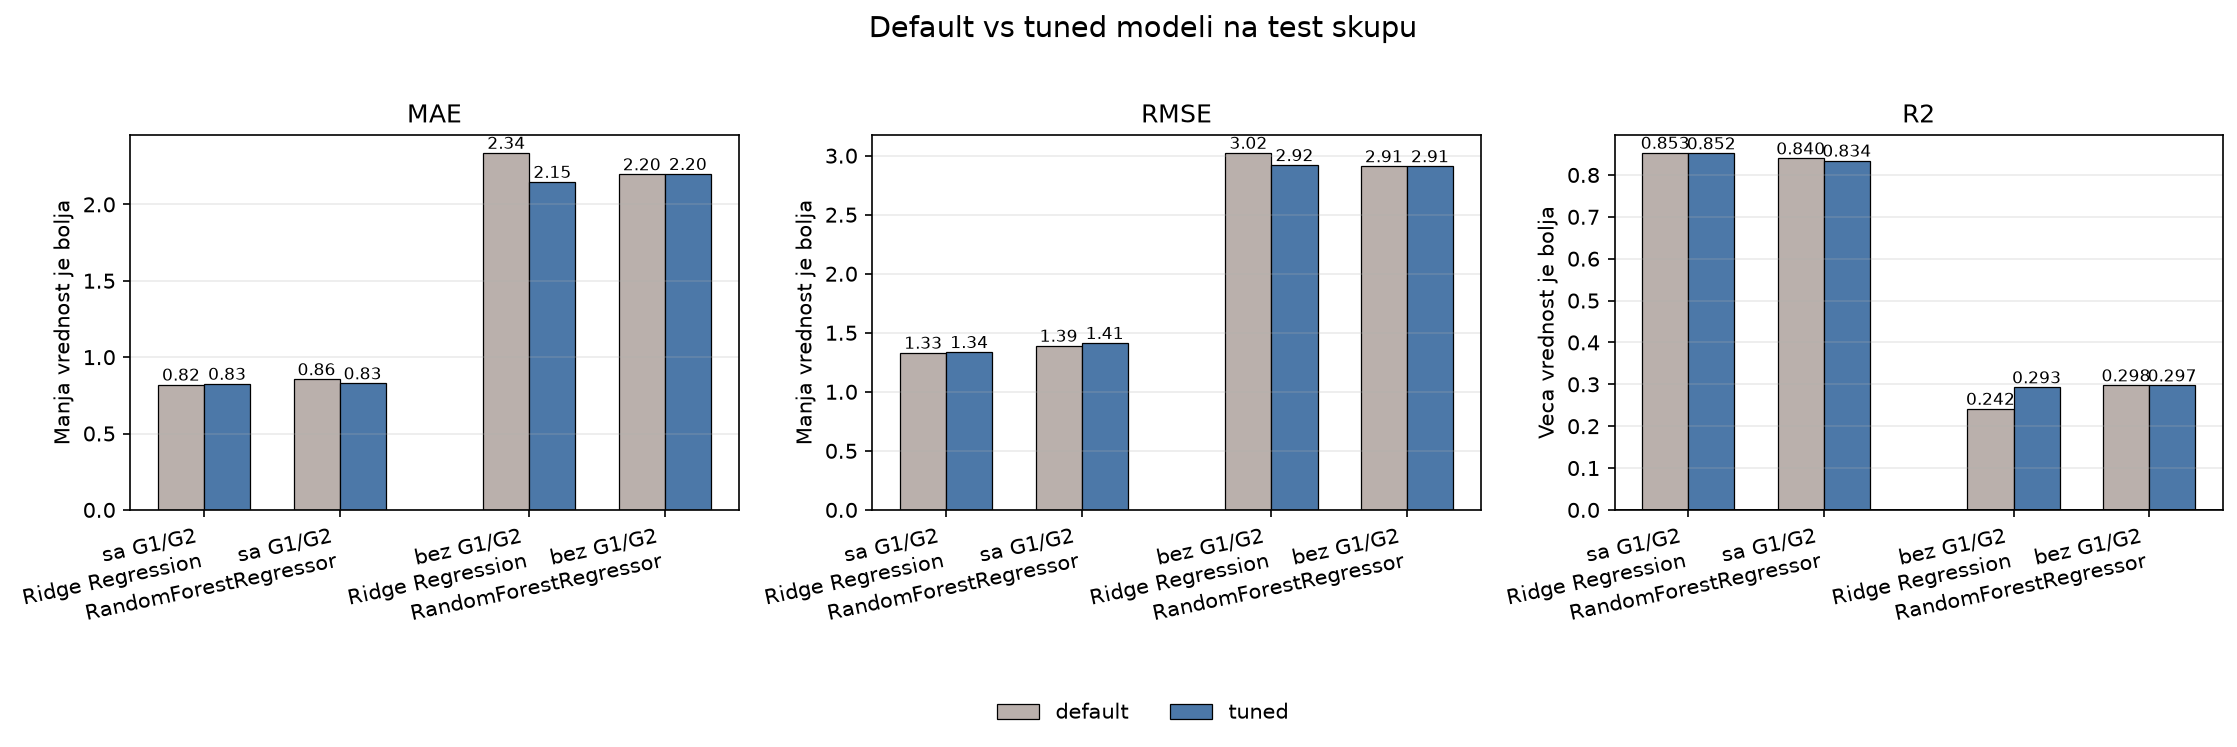

In [9]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

STEP07_GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "step07_tuning_graphs"

from IPython.display import Image, display

step07_graph_paths = [
    ("Default vs tuned - validation", STEP07_GRAPHS_DIR / "default_vs_tuned_validation.png"),
    ("Default vs tuned - test", STEP07_GRAPHS_DIR / "default_vs_tuned_test.png"),
]

for title, graph_path in step07_graph_paths:
    print(title)
    display(Image(filename=str(graph_path)))


## Tumačenje Step 07 grafika

Na validation grafiku se vidi da tuning uglavnom poboljšava rezultate. Kod scenarija `with_G1_G2`, posebno se vidi poboljšanje Random Forest modela: MAE i RMSE su manji, a R2 je veći. To znači da podešavanje parametara kao što su `max_depth` i `min_samples_leaf` pomaže modelu da bolje generalizuje na validation skupu.

Kod scenarija `without_G1_G2`, tuning takođe donosi određeno poboljšanje, naročito kod Ridge modela. Ipak, rezultati bez `G1/G2` ostaju znatno slabiji od rezultata sa `G1/G2`, što potvrđuje da prethodne ocene nose najveći deo informacije za predikciju završne ocene `G3`.

Test graf je posebno važan jer pokazuje da tuning ne mora uvek da popravi rezultat na potpuno odvojenom skupu. Na nekim mestima tuned model ima sličan ili malo slabiji test rezultat od default modela. To nije greška, već realan signal da izbor hiperparametara prema validation skupu ne garantuje automatski bolje ponašanje na test skupu.

Zbog toga se tuned rezultati ne posmatraju izolovano. Kasnije, pri izboru finalnog modela, treba zajedno gledati validation rezultat, test rezultat, stabilnost modela, praktičnu upotrebljivost scenarija i feature importance analizu.


## Zaključak posle sedmog koraka

Step 07 potvrđuje da je hyperparameter tuning koristan, ali da nije dovoljno gledati samo validation rezultat. Grafici jasno pokazuju razliku između default i tuned modela kroz `MAE`, `RMSE` i `R2`, i pomažu da se rezultati lakše objasne u dokumentaciji.

Glavni zaključak ostaje isti: modeli sa `G1/G2` su mnogo precizniji, dok su modeli bez `G1/G2` slabiji, ali praktično značajni jer ne zavise od prethodnih ocena.

Sledeći korak je feature importance analiza, gde treba utvrditi koji atributi najviše utiču na predikciju `G3`.


# Step 08 - Feature importance analiza

U osmom koraku urađena je feature importance analiza kroz fajl `src/step08_feature_importance.py`. Cilj ovog koraka je da se utvrdi koje atribute `RandomForestRegressor` najviše koristi pri predikciji završne ocene `G3`.

Feature importance je urađen za oba dogovorena scenarija:

- `with_G1_G2`: koriste se svi atributi osim `G3`, uključujući prethodne ocene `G1` i `G2`;
- `without_G1_G2`: izbacuju se `G1`, `G2` i `G3`, pa model mora da koristi ostale demografske, školske i ponašajne atribute.

Korišćen je tuned `RandomForestRegressor` iz Step 06. Za scenario `with_G1_G2` korišćeni su parametri `n_estimators=100`, `max_depth=5` i `min_samples_leaf=5`. Za scenario `without_G1_G2` korišćeni su parametri `n_estimators=100`, `max_depth=10` i `min_samples_leaf=2`.


## Feature importance report

Pošto se kategorijske kolone obrađuju pomoću `OneHotEncoder`, jedna originalna kolona može postati više transformisanih dummy kolona. Zbog toga su napravljena dva izveštaja:

- `feature_importance_detailed_report.csv` prikazuje importance za svaku transformisanu kolonu;
- `feature_importance_report.csv` agregira dummy kolone nazad na originalne atribute, što je čitljivije za dokumentaciju i tumačenje rezultata.

U nastavku se prikazuje agregirani report, jer je on najkorisniji za objašnjenje rezultata.


In [ ]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

STEP08_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step08_feature_importance"
STEP08_GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "step08_feature_importance"

feature_importance_report = pd.read_csv(STEP08_LOGS_DIR / "feature_importance_report.csv")
feature_importance_report


## Grafici feature importance

Sledeća ćelija prikazuje zajednički grafik sa oba scenarija. Levi deo prikazuje scenario sa `G1/G2`, a desni deo scenario bez `G1/G2`.


In [ ]:
from IPython.display import Image, display

display(Image(filename=str(STEP08_GRAPHS_DIR / "feature_importance.png")))


## Tumačenje rezultata Step 08

U scenariju `with_G1_G2` najvažniji atribut je `G2`. To znači da druga periodična ocena nosi najveći deo informacije za predikciju završne ocene `G3`. Ovo je očekivano, jer je `G2` vremenski najbliža završnoj oceni i u EDA analizi je imala najjaču korelaciju sa `G3`. Posle nje se pojavljuju `absences`, `G1`, `age` i `reason`, ali sa znatno manjim importance vrednostima.

U scenariju `without_G1_G2` model nema prethodne ocene, pa najviše koristi druge atribute. Najvažniji su `failures`, `reason`, `absences`, `school` i `higher`. Ovaj scenario je praktično važan jer pokazuje koji atributi nose signal kada prethodne ocene nisu dostupne. Ipak, raniji rezultati modela pokazuju da je predikcija bez `G1` i `G2` znatno slabija.

Važno je naglasiti da feature importance ne dokazuje uzročno-posledičnu vezu. On pokazuje koje atribute je Random Forest najviše koristio za smanjenje greške predikcije. Zato ove rezultate treba koristiti kao pomoć za objašnjenje modela i kao osnovu za sledeći korak, odnosno definisanje `top_features` scenarija.


## Zaključak posle osmog koraka

Step 08 potvrđuje da su prethodne ocene, posebno `G2`, dominantne kada su dostupne. Kada se `G1` i `G2` uklone, najkorisniji signali dolaze iz atributa koji opisuju prethodne neuspehe, izostanke, razlog izbora škole i obrazovne aspiracije učenika.

Sledeći korak je Step 09, gde se na osnovu feature importance rezultata definiše `top_features` scenario i porede modeli trenirani na najvažnijim atributima sa scenarijima `with_G1_G2` i `without_G1_G2`.
